In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import random
import matplotlib.pyplot as plt

import tensorflow as tf
from keras import utils
from keras.models import Sequential
from keras.layers import Input, Conv2D, MaxPooling2D, BatchNormalization, Dropout, Flatten, Dense
from keras.optimizers import Adam

In [2]:
from keras.datasets import cifar10
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [3]:
print("X_train shape", X_train.shape)
print("y_train shape", y_train.shape)
print("X_test shape", X_test.shape)
print("y_test shape", y_test.shape)

X_train shape (50000, 32, 32, 3)
y_train shape (50000, 1)
X_test shape (10000, 32, 32, 3)
y_test shape (10000, 1)


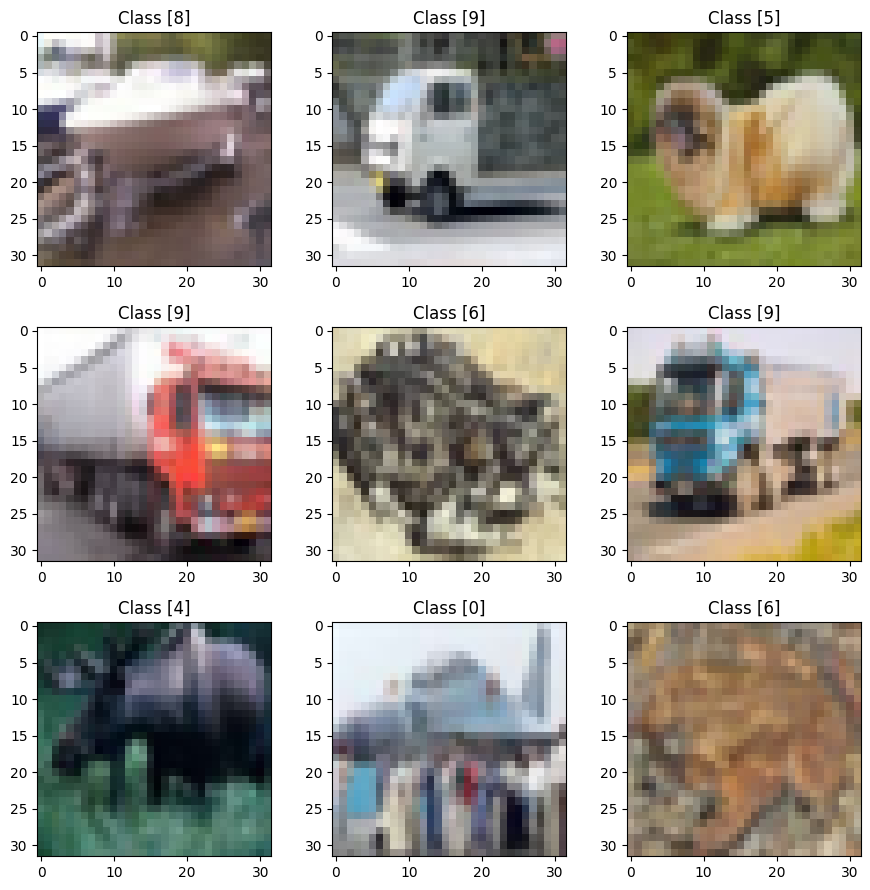

In [4]:
plt.rcParams['figure.figsize'] = (9,9)

for i in range(9):
    plt.subplot(3,3,i+1)
    num = random.randint(0, len(X_train))
    plt.imshow(X_train[num], cmap='gray', interpolation='none')
    plt.title("Class {}".format(y_train[num]))

plt.tight_layout()

In [5]:
X_train = X_train.astype('float32') / 255  # конвертируем данные в формат float
X_test = X_test.astype('float32') / 255    # нормируем каждый пиксель

print("Training matrix shape", X_train.shape)
print("Testing matrix shape", X_test.shape)

Training matrix shape (50000, 32, 32, 3)
Testing matrix shape (10000, 32, 32, 3)


In [6]:
classes = 10
# переводим числа, которые хранятся в "y" в классы, т.е. распределение вероятности
# тогда сеть сможет давать ответ на основе наибольшего из чисел [0, 0.9, 0.1, 0, 0, ..., 0] -> 1
y_train_cat = utils.to_categorical(y_train, classes)
y_test_cat = utils.to_categorical(y_test, classes)

In [7]:
model = Sequential()

In [8]:
# 1 блок(32x32): Conv32 - Batch_norm - Conv32 -  Batch_norm - Max_pooling32 - Dropout
model.add(Input(shape=(32, 32, 3)))                              # форма входа
model.add(Conv2D(32, (3, 3), activation="relu", padding="same"))  # свёрточный слой
model.add(BatchNormalization())                                  # нормализация батча
model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
model.output_shape

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


(None, 16, 16, 32)

In [9]:
# 2 блок(16x16): Conv64 - Batch_norm - Conv64 -  Batch_norm - Max_pooling64 - Dropout
model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
model.output_shape

(None, 8, 8, 64)

In [10]:
# 3 блок(8x8): Conv128 - Batch_norm - Conv128 -  Batch_norm - Max_pooling128 - Dropout
model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
model.output_shape

(None, 4, 4, 128)

In [11]:
# 4 блок(4x4): Conv256 - Batch_norm - Conv256 -  Batch_norm - Max_pooling256 - Dropout
model.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
model.output_shape

(None, 2, 2, 256)

In [12]:
# 5 блок
model.add(Flatten())
print(model.output_shape)
model.add(Dense(512, activation='relu'))
print(model.output_shape)
model.add(Dropout(0.5))
model.add(Dense(classes, activation='softmax')) # "результат работы сети"
print(model.output_shape)

(None, 1024)
(None, 512)
(None, 10)


In [13]:
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 4, 4, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,706,026 (6.51 MB)

 Trainable params: 1,704,106 (6.50 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [15]:
# Гиперпараметры
epochs = 25
batch_size = 64

# Обучение
history = model.fit(X_train, y_train_cat,
                    batch_size=batch_size,
                    epochs=epochs,
                    validation_data=(X_test, y_test_cat),
                    verbose=1)

Epoch 1/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 25ms/step - accuracy: 0.3391 - loss: 1.9525 - val_accuracy: 0.5583 - val_loss: 1.2530
Epoch 2/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.5861 - loss: 1.1794 - val_accuracy: 0.6312 - val_loss: 1.0754
Epoch 3/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.6764 - loss: 0.9373 - val_accuracy: 0.7099 - val_loss: 0.8703
Epoch 4/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.7267 - loss: 0.7958 - val_accuracy: 0.7249 - val_loss: 0.8206
Epoch 5/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.7551 - loss: 0.7187 - val_accuracy: 0.7776 - val_loss: 0.6531
Epoch 6/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.7853 - loss: 0.6328 - val_accuracy: 0.7919 - val_loss: 0.6336
Epoch 7/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.8043 - loss: 0.5756 - val_accuracy: 0.8002 - val_loss: 0.6044
Epoch 8/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.8222 - loss: 0.5285 - val_a


Точность на тестовом наборе: 85.03%


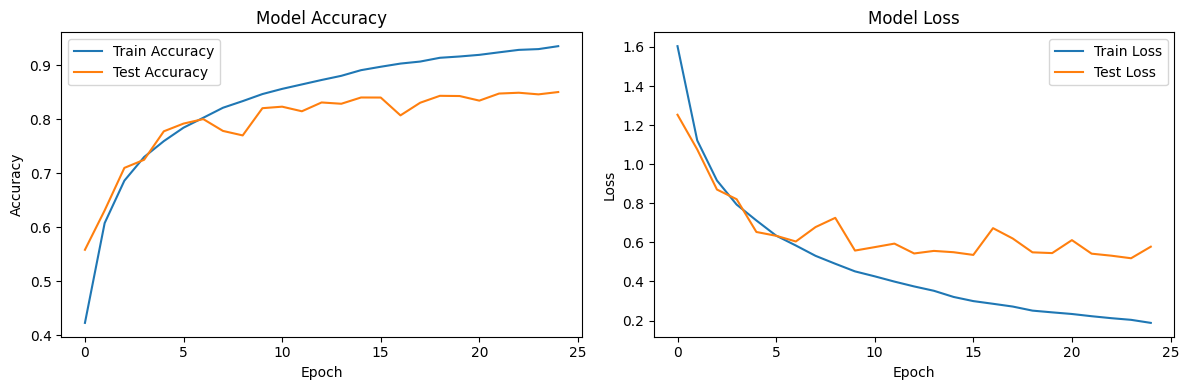

In [16]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"\nТочность на тестовом наборе: {test_acc * 100:.2f}%")

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

Прунинг

In [17]:
from keras import models, layers, ops

In [18]:
pruned_model = models.clone_model(model)
pruned_model.set_weights(model.get_weights()) # установка весов из старой в новую модель
pruned_model.compile(optimizer=Adam(learning_rate=0.001),
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

current_weights = pruned_model.get_weights() # начальные веса прун. модели

In [19]:
n_iterations = 5
base_threshold = 0.05  # если < base_threshold - убираем веса

for it in range(1, n_iterations + 1):
    print(f"\n Итерация прунинга {it}")

    threshold = base_threshold * it # с ходом итераций порог для весов растёт

    new_weights = []
    for w in current_weights:
        if w.ndim == 0: # если w - просто скаляр, то добавляем его без обработки
            new_weights.append(w)
            continue

        flat = w.flatten()
        flat_pruned = np.array([0.0 if abs(v) < threshold else v for v in flat]) # если вес меньше порога, заменяем на 0
        new_w = flat_pruned.reshape(w.shape)
        new_weights.append(new_w)

    pruned_model.set_weights(new_weights)
    current_weights = new_weights

    epochs = 1 if it < n_iterations else 5
    print(f"Fine-tuning: {epochs} эпох")
    pruned_model.fit(
        X_train, y_train_cat,
        batch_size=batch_size,
        epochs=epochs,
        validation_data=(X_test, y_test_cat),
        verbose=1
    )

    loss_it, acc_it = pruned_model.evaluate(X_test, y_test_cat, verbose=0)
    print(f"Точность после итерации {it}: {acc_it * 100:.2f}%")


 Итерация прунинга 1
Fine-tuning: 1 эпох
782/782 ━━━━━━━━━━━━━━━━━━━━ 31s 23ms/step - accuracy: 0.9353 - loss: 0.1900 - val_accuracy: 0.8414 - val_loss: 0.5958
Точность после итерации 1: 84.14%

 Итерация прунинга 2
Fine-tuning: 1 эпох
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9069 - loss: 0.2885 - val_accuracy: 0.8429 - val_loss: 0.5586
Точность после итерации 2: 84.29%

 Итерация прунинга 3
Fine-tuning: 1 эпох
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.8174 - loss: 0.5324 - val_accuracy: 0.8194 - val_loss: 0.6313
Точность после итерации 3: 81.94%

 Итерация прунинга 4
Fine-tuning: 1 эпох
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.6480 - loss: 0.9792 - val_accuracy: 0.8169 - val_loss: 0.5660
Точность после итерации 4: 81.69%

 Итерация прунинга 5
Fine-tuning: 5 эпох
Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.3773 - loss: 1.6594 - val_accuracy: 0.7030 - val_loss: 0.8597
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/st

Дистилляция

In [20]:
teacher = pruned_model # исходная пруненная модель

In [21]:
timesteps = 32
features = 32 * 3
num_classes = 10

X_train_seq = X_train.reshape((X_train.shape[0], timesteps, features))
X_test_seq  = X_test.reshape((X_test.shape[0], timesteps, features))

student = models.Sequential([
        layers.Input(shape=(timesteps, features)),
        layers.LSTM(128),
        layers.Dense(num_classes)
    ],
    name="student_lstm",
) # ученик - LSTM-сеть

In [22]:
import keras
class Distiller(keras.Model):
    def __init__(self, student, teacher):
        super().__init__()
        self.teacher = teacher
        self.student = student

    def compile(
        self,
        optimizer,
        metrics,
        student_loss_fn,
        distillation_loss_fn,
        alpha=0.1,
        temperature=3,
    ):
        super().compile(optimizer=optimizer, metrics=metrics)
        self.student_loss_fn = student_loss_fn
        self.distillation_loss_fn = distillation_loss_fn
        self.alpha = alpha
        self.temperature = temperature

    def compute_loss(self, x=None, y=None, y_pred=None, sample_weight=None, allow_empty=False):
        teacher_pred = self.teacher(x, training=False)
        student_loss = self.student_loss_fn(y, y_pred)
        distillation_loss = self.distillation_loss_fn(
            ops.softmax(teacher_pred / self.temperature, axis=1),
            ops.softmax(y_pred / self.temperature, axis=1),
        ) * (self.temperature ** 2)

        return self.alpha * student_loss + (1 - self.alpha) * distillation_loss

    def call(self, x):
        return self.student(x)

In [23]:
teacher_input = keras.Input(shape=(timesteps, features))
x_img = layers.Reshape((32, 32, 3))(teacher_input)
teacher_out = teacher(x_img)
teacher_for_distill = keras.Model(teacher_input, teacher_out, name="teacher_for_distill")

distiller = Distiller(student=student, teacher=teacher_for_distill)
alpha = 0.1
temperature = 3

In [24]:
distiller.compile(
    optimizer = keras.optimizers.Adam(),
    metrics = [keras.metrics.CategoricalAccuracy()],
    student_loss_fn = keras.losses.CategoricalCrossentropy(from_logits=True),
    distillation_loss_fn = keras.losses.KLDivergence(),
    alpha = alpha,
    temperature = temperature,
)

distiller.fit(
    X_train_seq,
    y_train_cat,
    batch_size=batch_size,
    epochs=25,
    validation_data=(X_test_seq, y_test_cat),
    verbose=1,
)

Epoch 1/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 22ms/step - categorical_accuracy: 0.2378 - loss: 0.2268 - val_categorical_accuracy: 0.3706 - val_loss: 0.2106
Epoch 2/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - categorical_accuracy: 0.3818 - loss: 0.2097 - val_categorical_accuracy: 0.4172 - val_loss: 0.2049
Epoch 3/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - categorical_accuracy: 0.4316 - loss: 0.2040 - val_categorical_accuracy: 0.4643 - val_loss: 0.2005
Epoch 4/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - categorical_accuracy: 0.4681 - loss: 0.2000 - val_categorical_accuracy: 0.4843 - val_loss: 0.1991
Epoch 5/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - categorical_accuracy: 0.4901 - loss: 0.1971 - val_categorical_accuracy: 0.5057 - val_loss: 0.1959
Epoch 6/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - categorical_accuracy: 0.5108 - loss: 0.1951 - val_categorical_accuracy: 0.5134 - val_loss: 0.1956
Epoch 7/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - categorical_accuracy

In [25]:
distiller.evaluate(X_test_seq, y_test_cat, verbose=1) # точность ученика на тестовой

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - categorical_accuracy: 0.5892 - loss: 0.1910


[0.19182951748371124, 0.5825999975204468]

Подбор размеров слоёв

In [26]:
lstm_sizes = [512, 256, 128, 64, 32, 16]
dense_sizes = [128, 64, 32, 16, 10]

In [27]:
def build_student(lstm_size, dense_size):
    model = models.Sequential(
        [
            layers.Input(shape=(timesteps, features)),
            layers.LSTM(lstm_size),
            layers.Dense(dense_size, activation="relu") if dense_size != num_classes else layers.Dense(num_classes),
        ],
        name=f"student_lstm_{lstm_size}_{dense_size}",
    )
    # если dense_size != num_classes, нужен ещё выходной слой на 10
    if dense_size != num_classes:
        model.add(layers.Dense(num_classes))
    return model


In [ ]:
target_acc = test_acc
print("Точность исходной CNN:", target_acc)

results = []

for lstm_size in lstm_sizes:
    for dense_size in dense_sizes:
        print(f"\nLSTM {lstm_size}, Dense {dense_size}")

        student = build_student(lstm_size, dense_size)

        distiller = Distiller(student=student, teacher=teacher_for_distill)
        distiller.compile(
            optimizer=keras.optimizers.Adam(),
            metrics=[keras.metrics.CategoricalAccuracy()],
            student_loss_fn=keras.losses.CategoricalCrossentropy(from_logits=True),
            distillation_loss_fn=keras.losses.KLDivergence(),
            alpha=0.1,
            temperature=10,
        )

        history = distiller.fit(
            X_train_seq,
            y_train_cat,
            batch_size=batch_size,
            epochs=5,
            validation_data=(X_test_seq, y_test_cat),
            verbose=0,
        )

        loss_s, acc_s = distiller.evaluate(X_test_seq, y_test_cat, verbose=0)
        print(f"Точность студента: {acc_s:.4f}")

        results.append((lstm_size, dense_size, acc_s))

print("\nВарианты не хуже исходной CNN:")
for lstm_size, dense_size, acc_s in results:
    if acc_s >= target_acc:
        print(f"LSTM={lstm_size}, Dense={dense_size}, acc={acc_s:.4f}")


Точность исходной CNN: 0.8503000140190125

LSTM 512, Dense 128
Точность студента: 0.5567

LSTM 512, Dense 64
Точность студента: 0.5528

LSTM 512, Dense 32
Точность студента: 0.1000

LSTM 512, Dense 16
Точность студента: 0.1000

LSTM 512, Dense 10
Точность студента: 0.5306

LSTM 256, Dense 128
Точность студента: 0.5265

LSTM 256, Dense 64
Точность студента: 0.5264

LSTM 256, Dense 32
Точность студента: 0.1000

LSTM 256, Dense 16
